# Clusterização com K-Means

Este notebook é parte de um trabalho acadêmico sobre **Clusterização**, desenvolvido para a disciplina de **Aprendizado de Máquina Não Supervisionado** do curso de **Tecnologia em Ciência de Dados** da **Faculdade de Tecnologia e Inovação Senac DF**, sob orientação do professor **Rogério Gomes Lopes**.  

O objetivo é aplicar técnicas de **aprendizado não supervisionado** para analisar a **Distribuição de Renda** disponibilizada no portal de **dados abertos da Receita Federal**, utilizando métodos de pré-processamento, normalização, clusterização (K-Means) e visualizações gráficas (incluindo gráficos de teia/radar).  

### Equipe
- **Anderson de Matos Guimarães**  
- **Gustavo Stefano Thomazinho**  
- **Renan Ost**  

Este projeto tem caráter avaliativo e corresponde à **nota parcial do 1º Bimestre** da disciplina.


## Bibliotecas e Funções — Ajustes do Ambiente

> **Observação:** o notebook original do professor foi construído no **Google Colab**, que possui algumas funcionalidades específicas não compatíveis diretamente com o ambiente local (Windows + VS Code + Python 3.13.17 + Bash integrado).  
> Para manter o código **o mais fiel possível** ao original, foram feitas adaptações mínimas:

### 🔴 Código original no Google Colab
```python
!pip install pyvis
from google.colab import files
```

- `!pip install pyvis` — no Colab, instala pacotes diretamente no notebook.  
- `from google.colab import files` — usado para baixar arquivos gerados.

### 🟢 Código adaptado para VS Code
```bash
# Executar no terminal Bash apenas uma vez (fora do notebook)
pip install pyvis networkx
```

```python
# Imports agora ficam assim
import networkx as nx
from pyvis.network import Network
# Removemos a dependência de google.colab
```

### ⚠️ Observação sobre o código
- As funções `make_graph` e `make_graph2` foram herdadas de exemplos de **regras de associação em supermercados** (por isso o nome do arquivo `supermarket_associations_directed.html`).  
- Para manter o notebook fiel ao professor, o código foi mantido.  
- No contexto da Receita Federal, provavelmente **não utilizaremos essas funções**; nossa ênfase estará em **clustering (K-Means)** e **visualizações em scatter/radar**.  
- Apenas ajustamos o nome do arquivo de saída para algo mais coerente:  
```python
net.save_graph("clusters_renda.html")
print("✅ Arquivo salvo: clusters_renda.html")
```

Assim, garantimos compatibilidade com o ambiente local e clareza no resultado.


In [1]:
import warnings
warnings.filterwarnings("ignore", category=DeprecationWarning)

import pandas as pd
import random
import networkx as nx
from pyvis.network import Network

pd.set_option('display.max_colwidth', None)

def make_graph(grules):
    # Criando a rede com pyvis
    net = Network(height="750px", width="100%", bgcolor="#222222",
                  font_color="white", notebook=True, directed=True,
                  cdn_resources='in_line')

    # Adicionando nós e arestas com setas
    for index, row in grules.iterrows():
        antecedents = list(row['antecedents'])
        consequents = list(row['consequents'])

        for ant in antecedents:
            net.add_node(ant, ant, title=ant)

        for con in consequents:
            net.add_node(con, con, title=con)

        for ant in antecedents:
            for con in consequents:
                edge_title = f"Confidence: {row['confidence']:.2f}, Lift: {row['lift']:.2f}"
                net.add_edge(ant, con, value=row['confidence'], title=edge_title)

    # Salvando o grafo localmente
    net.save_graph("clusters_renda.html")
    print("✅ Arquivo salvo: clusters_renda.html")


def make_graph2(grules):
    G = nx.DiGraph()

    for index, row in grules.iterrows():
        antecedent_items = sorted(map(str, row['antecedents']))
        consequent_items = sorted(map(str, row['consequents']))
        antecedent_label = ', '.join(antecedent_items)
        consequent_label = ', '.join(consequent_items)

        if not G.has_node(antecedent_label):
            G.add_node(antecedent_label, title=antecedent_label)
        if not G.has_node(consequent_label):
            G.add_node(consequent_label, title=consequent_label)

        G.add_edge(
            antecedent_label,
            consequent_label,
            title=f"Confiança: {row['confidence']:.2f}, Lift: {row['lift']:.2f}",
            confidence=row['confidence'],
            lift=row['lift']
        )

    net = Network(height="750px", width="100%", bgcolor="#222222",
                  font_color="white", notebook=True, directed=True,
                  cdn_resources='in_line')

    net.from_nx(G)

    for node in net.nodes:
        node_label = node['label']
        node['title'] = node_label
        node['shape'] = 'box'

        if ',' not in node_label:
            if node_label.startswith('DS_cluster'):
                node['color'] = 'red'
                node['font'] = {'size': 14}
                node['borderWidth'] = 2
                node['size'] = 40
            else:
                node['color'] = '#1f78b4'
                node['size'] = 5
                node['font'] = {'size': 2}
        else:
            node['color'] = '#6a3d9a'
            node['size'] = 5
            node['font'] = {'size': 2}

    for edge in net.edges:
        edge['title'] = edge['title']
        edge['value'] = edge['confidence']

    net.show_buttons(filter_=['physics'])
    net.toggle_physics(True)

    net.save_graph("clusters_renda.html")
    print("✅ Arquivo salvo: clusters_renda.html")


## Obtenção dos Dados — Ajustes do Ambiente

> **Observação:** no notebook original do professor (Projeto IDEB), os dados eram baixados em um arquivo `.zip` e depois descompactados com a função `descompactar_arquivo()`.  
> No nosso caso, os dados da Receita Federal já foram **baixados previamente** e estão disponíveis no arquivo **`distribuicao-renda.csv`** localizado na raiz do projeto.

### 🔴 Código original do professor
```python
import zipfile
def descompactar_arquivo(nome_arquivo_zip, destino):
    with zipfile.ZipFile(nome_arquivo_zip, 'r') as zip_ref:
        zip_ref.extractall(destino)
```

### 🟢 Código adaptado
- Não é necessário descompactar nada.  
- Vamos apenas **carregar diretamente o arquivo CSV** já salvo em disco.  
- Para referência e reprodutibilidade, registramos a **fonte oficial dos dados**:  
  [Portal de Dados Abertos — Receita Federal](https://dados.gov.br/dados/conjuntos-dados/distribuio-de-renda#:~:text=Esta%20base%20cont%C3%A9m%20a%20distribui%C3%A7%C3%A3o%20da%20renda%20apurada,em%20n%C3%ADvel%20nacional%20e%20por%20unidade%20da%20federa%C3%A7%C3%A3o.)

### ✅ Resultado esperado
- O notebook passa a ler diretamente o arquivo **`distribuicao-renda.csv`** da raiz do diretório.  
- Isso elimina a necessidade de lidar com `.zip`, mas mantém a lógica de organização do professor (seção de obtenção dos dados).


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import math
from matplotlib import colormaps

# Fonte dos dados: Receita Federal - Distribuição de Renda
# https://dados.gov.br/dados/conjuntos-dados/distribuio-de-renda#:~:text=Esta%20base%20cont%C3%A9m%20a%20distribui%C3%A7%C3%A3o%20da%20renda%20apurada,em%20n%C3%ADvel%20nacional%20e%20por%20unidade%20da%20federa%C3%A7%C3%A3o.

# Carregar diretamente o CSV já disponível na raiz do projeto
df = pd.read_csv("distribuicao-renda.csv", sep=";", encoding="utf-8")

print("✅ Arquivo 'distribuicao-renda.csv' carregado com sucesso.")
print(f"Dimensões do dataset: {df.shape}")
print("Visualizando as primeiras linhas:")
display(df.head())


✅ Arquivo 'distribuicao-renda.csv' carregado com sucesso.
Dimensões do dataset: (46350, 24)
Visualizando as primeiras linhas:


,Ano-calendário,Ente Federativo,Centil,Quantidade de Contribuintes,Rendimentos Tributaveis - Limite Superior da RTB do Centil [R$ milhões],Rendimentos Tributaveis - Soma da RTB do Centil [R$ milhões],Rendimentos Tributaveis - RTB Acumulada do Centil [R$ milhões],Rendimentos Tributaveis - Média da RTB do Centil [R$],Rendimentos Sujeitos à Tribut. Exclusiva [R$ milhões],Rendimentos Isentos - Lucros e dividendos [R$ milhões],...,Despesas Dedutíveis - Instrução [R$ milhões],Despesas Dedutíveis - Médicas [R$ milhões],Despesas Dedutíveis - Pensão Alimentícia [R$ milhões],Despesas Dedutíveis - Livro-Caixa [R$ milhões],Imposto Devido [R$ milhões],Bens e Direitos - Imóveis [R$ milhões],Bens e Direitos - Móveis [R$ milhões],Bens e Direitos - Financeiros [R$ milhões],Bens e Direitos - Outros Bens e Direitos [R$ milhões],Dívidas e Ônus [R$ milhões]
0,2006,BRASIL,1,241.563,NaN,NaN,NaN,NaN,"235,61","481,27",...,NaN,NaN,NaN,NaN,"0,16","5.281,59","686,21","6.549,15","1.006,40","1.610,39"
1,2006,BRASIL,2,241.563,NaN,NaN,NaN,NaN,"208,74","483,44",...,NaN,NaN,NaN,NaN,"0,22","5.295,48","668,82","5.762,77","681,75","694,12"
2,2006,BRASIL,3,241.562,NaN,NaN,NaN,NaN,"219,96","459,87",...,NaN,NaN,NaN,NaN,"0,31","5.566,27","670,64","5.451,95","377,17","650,98"
3,2006,BRASIL,4,241.563,NaN,NaN,NaN,NaN,"257,01","481,93",...,NaN,NaN,NaN,NaN,"0,17","5.860,02","678,44","6.104,09","256,16","1.079,20"
4,2006,BRASIL,5,241.562,NaN,NaN,NaN,NaN,"249,88","464,23",...,NaN,NaN,NaN,NaN,"0,17","5.193,31","682,38","5.592,52","269,28","671,97"


## Obtenção e preparação inicial dos dados — adaptação Receita Federal

> **Contexto do professor (IDEB):** leitura de **Excel** com **cabeçalhos em 3 linhas (7–9)**, seguida de *flatten* dos níveis e limpeza de nomes de coluna (`Unnamed`, `level_x`), pois o arquivo não vinha com cabeçalhos “planos”.

> **Nosso contexto (Receita):** leitura de **CSV** já com **cabeçalhos planos** (ex.: `Ano-calendário`, `Ente Federativo`, `Centil`, etc.).  
> Aqui **não precisamos** “achatar” cabeçalhos nem remover linhas do topo. Em vez disso, precisamos:
> 1) **Ler o CSV** da raiz do projeto;  
> 2) **Converter números no formato brasileiro** (ponto de milhar e vírgula decimal) para `float`;  
> 3) Garantir *dtypes* coerentes: `Ano-calendário` (`int`), `Centil` (`str`), `Quantidade de Contribuintes` (`int`), demais métricas `float`.

### 🔴 Trecho do professor (IDEB) — **não se aplica** ao CSV da Receita
```python
arquivo_excel = 'divulgacao_anos_finais_municipios_2023.xlsx'
df = pd.read_excel(arquivo_excel, header=[6, 7, 8])
df.columns = ['_'.join([...]) for col in df.columns.values]
df = df.iloc[1:].reset_index(drop=True)
# limpeza de 'Unnamed', 'level_x', etc.
```

### 🟢 Adaptação para a Receita (CSV)
- Leitura direta do `distribuicao-renda.csv` (raiz do projeto);  
- Conversão numérica segura com respeito ao padrão brasileiro;  
- Checagens rápidas do resultado (shape, amostra do head).

**Observação:** é esperado ver `NaN` em algumas colunas nos primeiros anos (ex.: séries não preenchidas em 2006), pois a série histórica evolui ao longo do tempo. Isso não é erro do parser.


In [3]:
import pandas as pd
import numpy as np

# 1) Leitura direta do CSV (raiz do projeto)
#    Se o arquivo vier com separador ';' (comum em dados BR), mantenha 'sep=";"'
df = pd.read_csv("distribuicao-renda.csv", sep=";", encoding="utf-8")

print("✅ CSV carregado:", df.shape)
display(df.head())

# 2) Conversão numérica para colunas monetárias e contagens
#    Regra: remover ponto de milhar e trocar vírgula por ponto
def br_to_numeric(s):
    return pd.to_numeric(
        s.astype(str)
         .str.replace(".", "", regex=False)
         .str.replace(",", ".", regex=False),
        errors="coerce"
    )

# Colunas monetárias (em R$ milhões) + média em R$ e contagem de contribuintes
num_cols = [c for c in df.columns if "[" in c] + ["Quantidade de Contribuintes"]

for c in num_cols:
    if c in df.columns:
        df[c] = br_to_numeric(df[c])

# 3) Tipos básicos coerentes
if "Ano-calendário" in df.columns:
    df["Ano-calendário"] = pd.to_numeric(df["Ano-calendário"], errors="coerce").astype("Int64")
if "Centil" in df.columns:
    df["Centil"] = df["Centil"].astype(str)
if "Quantidade de Contribuintes" in df.columns:
    # após a conversão pode ficar float; voltamos para inteiro quando possível
    df["Quantidade de Contribuintes"] = df["Quantidade de Contribuintes"].round().astype("Int64")

print("\n📊 Tipos após conversão:")
print(df.dtypes.head(12))

print("\n🔎 Amostra após conversão:")
display(df.head())

# 4) (Opcional) padronização leve de nomes (sem quebrar o dicionário oficial)
#    Útil apenas se você quiser usar colunas com .select_dtypes etc. sem acentos/espacos.
#    Comente se preferir manter exatamente como no CSV.
# df.columns = (df.columns
#               .str.replace(r"\s+", " ", regex=True)
#               .str.strip())

# 5) Sanidade rápida: anos e entes disponíveis
print("\n🗓️ Anos disponíveis:", sorted(df["Ano-calendário"].dropna().unique().tolist())[:5], "...", sorted(df["Ano-calendário"].dropna().unique().tolist())[-5:])
print("🏷️ Entes (amostra):", df["Ente Federativo"].dropna().unique()[:10])


✅ CSV carregado: (46350, 24)


,Ano-calendário,Ente Federativo,Centil,Quantidade de Contribuintes,Rendimentos Tributaveis - Limite Superior da RTB do Centil [R$ milhões],Rendimentos Tributaveis - Soma da RTB do Centil [R$ milhões],Rendimentos Tributaveis - RTB Acumulada do Centil [R$ milhões],Rendimentos Tributaveis - Média da RTB do Centil [R$],Rendimentos Sujeitos à Tribut. Exclusiva [R$ milhões],Rendimentos Isentos - Lucros e dividendos [R$ milhões],...,Despesas Dedutíveis - Instrução [R$ milhões],Despesas Dedutíveis - Médicas [R$ milhões],Despesas Dedutíveis - Pensão Alimentícia [R$ milhões],Despesas Dedutíveis - Livro-Caixa [R$ milhões],Imposto Devido [R$ milhões],Bens e Direitos - Imóveis [R$ milhões],Bens e Direitos - Móveis [R$ milhões],Bens e Direitos - Financeiros [R$ milhões],Bens e Direitos - Outros Bens e Direitos [R$ milhões],Dívidas e Ônus [R$ milhões]
0,2006,BRASIL,1,241.563,NaN,NaN,NaN,NaN,"235,61","481,27",...,NaN,NaN,NaN,NaN,"0,16","5.281,59","686,21","6.549,15","1.006,40","1.610,39"
1,2006,BRASIL,2,241.563,NaN,NaN,NaN,NaN,"208,74","483,44",...,NaN,NaN,NaN,NaN,"0,22","5.295,48","668,82","5.762,77","681,75","694,12"
2,2006,BRASIL,3,241.562,NaN,NaN,NaN,NaN,"219,96","459,87",...,NaN,NaN,NaN,NaN,"0,31","5.566,27","670,64","5.451,95","377,17","650,98"
3,2006,BRASIL,4,241.563,NaN,NaN,NaN,NaN,"257,01","481,93",...,NaN,NaN,NaN,NaN,"0,17","5.860,02","678,44","6.104,09","256,16","1.079,20"
4,2006,BRASIL,5,241.562,NaN,NaN,NaN,NaN,"249,88","464,23",...,NaN,NaN,NaN,NaN,"0,17","5.193,31","682,38","5.592,52","269,28","671,97"



📊 Tipos após conversão:
Ano-calendário                                                                   Int64
Ente Federativo                                                                 object
Centil                                                                          object
Quantidade de Contribuintes                                                      Int64
Rendimentos Tributaveis - Limite Superior da RTB do Centil [R$ milhões]        float64
Rendimentos Tributaveis - Soma da RTB do Centil [R$ milhões]                   float64
Rendimentos Tributaveis - RTB Acumulada do Centil [R$ milhões]                 float64
Rendimentos Tributaveis - Média da RTB do Centil [R$]                          float64
Rendimentos Sujeitos à Tribut. Exclusiva [R$ milhões]                          float64
Rendimentos Isentos - Lucros e dividendos [R$ milhões]                         float64
Rendimentos Isentos - Rendim. Sócio/Titular ME/EPP Opt SIMPLES [R$ milhões]    float64
Rendimentos Isento

,Ano-calendário,Ente Federativo,Centil,Quantidade de Contribuintes,Rendimentos Tributaveis - Limite Superior da RTB do Centil [R$ milhões],Rendimentos Tributaveis - Soma da RTB do Centil [R$ milhões],Rendimentos Tributaveis - RTB Acumulada do Centil [R$ milhões],Rendimentos Tributaveis - Média da RTB do Centil [R$],Rendimentos Sujeitos à Tribut. Exclusiva [R$ milhões],Rendimentos Isentos - Lucros e dividendos [R$ milhões],...,Despesas Dedutíveis - Instrução [R$ milhões],Despesas Dedutíveis - Médicas [R$ milhões],Despesas Dedutíveis - Pensão Alimentícia [R$ milhões],Despesas Dedutíveis - Livro-Caixa [R$ milhões],Imposto Devido [R$ milhões],Bens e Direitos - Imóveis [R$ milhões],Bens e Direitos - Móveis [R$ milhões],Bens e Direitos - Financeiros [R$ milhões],Bens e Direitos - Outros Bens e Direitos [R$ milhões],Dívidas e Ônus [R$ milhões]
0,2006,BRASIL,1,241563,NaN,NaN,NaN,NaN,235.61,481.27,...,NaN,NaN,NaN,NaN,0.16,5281.59,686.21,6549.15,1006.40,1610.39
1,2006,BRASIL,2,241563,NaN,NaN,NaN,NaN,208.74,483.44,...,NaN,NaN,NaN,NaN,0.22,5295.48,668.82,5762.77,681.75,694.12
2,2006,BRASIL,3,241562,NaN,NaN,NaN,NaN,219.96,459.87,...,NaN,NaN,NaN,NaN,0.31,5566.27,670.64,5451.95,377.17,650.98
3,2006,BRASIL,4,241563,NaN,NaN,NaN,NaN,257.01,481.93,...,NaN,NaN,NaN,NaN,0.17,5860.02,678.44,6104.09,256.16,1079.20
4,2006,BRASIL,5,241562,NaN,NaN,NaN,NaN,249.88,464.23,...,NaN,NaN,NaN,NaN,0.17,5193.31,682.38,5592.52,269.28,671.97



🗓️ Anos disponíveis: [2006, 2007, 2008, 2009, 2010] ... [2016, 2017, 2018, 2019, 2020]
🏷️ Entes (amostra): ['BRASIL' 'AC' 'AL' 'AM' 'AP' 'BA' 'CE' 'DF' 'ES' 'GO']


## Padronização dos nomes das colunas

> **Observação:** no CSV original da Receita Federal, os nomes das colunas são longos, com acentos, espaços e unidades (ex.:  
> `"Rendimentos Tributaveis - Média da RTB do Centil [R$]"`).  
> Isso é importante para fins documentais, mas dificulta a manipulação no código (ex.: seleção de variáveis, visualizações, clustering).

### Objetivos da padronização
- Criar **aliases curtos** e consistentes para cada variável.  
- Remover acentos, espaços e caracteres especiais, mantendo apenas letras minúsculas e `_`.  
- Facilitar a chamada das colunas no Pandas e na visualização do `df`.  
- **Não altera o CSV original** — apenas renomeia o DataFrame carregado em memória.

### Exemplo
- **Original:** `Rendimentos Tributaveis - Média da RTB do Centil [R$]`  
- **Alias:** `rtb_media`

### Fonte de referência
Os nomes curtos foram definidos a partir do **dicionário oficial da Receita Federal** (metadados).  


In [4]:
# Dicionário de renomeação baseado no PDF da Receita (metadados)
rename_dict = {
    "Ano-calendário": "ano",
    "Ente Federativo": "ente",
    "Centil": "centil",
    "Quantidade de Contribuintes": "qtd_contribuintes",
    "Rendimentos Tributaveis - Limite Superior da RTB do Centil [R$ milhões]": "rtb_limite_sup_mi",
    "Rendimentos Tributaveis - Soma da RTB do Centil [R$ milhões]": "rtb_soma_mi",
    "Rendimentos Tributaveis - RTB Acumulada do Centil [R$ milhões]": "rtb_acumulada_mi",
    "Rendimentos Tributaveis - Média da RTB do Centil [R$]": "rtb_media",
    "Rendimentos Sujeitos à Tribut. Exclusiva [R$ milhões]": "rend_exclusiva_mi",
    "Rendimentos Isentos - Lucros e dividendos [R$ milhões]": "isentos_dividendos_mi",
    "Rendimentos Isentos - Rendim. Sócio/Titular ME/EPP Opt SIMPLES [R$ milhões]": "isentos_simples_mi",
    "Rendimentos Isentos - Outros Rendimentos Isentos [R$ milhões]": "isentos_outros_mi",
    "Despesas Dedutíveis - Previdência [R$ milhões]": "dedut_previdencia_mi",
    "Despesas Dedutíveis - Dependentes [R$ milhões]": "dedut_dependentes_mi",
    "Despesas Dedutíveis - Instrução [R$ milhões]": "dedut_instrucao_mi",
    "Despesas Dedutíveis - Médicas [R$ milhões]": "dedut_medicas_mi",
    "Despesas Dedutíveis - Pensão Alimentícia [R$ milhões]": "dedut_pensao_mi",
    "Despesas Dedutíveis - Livro-Caixa [R$ milhões]": "dedut_livrocaixa_mi",
    "Imposto Devido [R$ milhões]": "imposto_mi",
    "Bens e Direitos - Imóveis [R$ milhões]": "bens_imoveis_mi",
    "Bens e Direitos - Móveis [R$ milhões]": "bens_moveis_mi",
    "Bens e Direitos - Financeiros [R$ milhões]": "bens_financeiros_mi",
    "Bens e Direitos - Outros Bens e Direitos [R$ milhões]": "bens_outros_mi",
    "Dívidas e Ônus [R$ milhões]": "dividas_onus_mi"
}

# Aplicar renomeação no DataFrame (em memória)
df = df.rename(columns=rename_dict)

print("✅ Colunas renomeadas com sucesso.")
print("🔎 Amostra dos novos nomes:")
print(df.columns.tolist()[:10])


✅ Colunas renomeadas com sucesso.
🔎 Amostra dos novos nomes:
['ano', 'ente', 'centil', 'qtd_contribuintes', 'rtb_limite_sup_mi', 'rtb_soma_mi', 'rtb_acumulada_mi', 'rtb_media', 'rend_exclusiva_mi', 'isentos_dividendos_mi']


## Estrutura e amostra dos dados após limpeza

> Após carregar o CSV da Receita Federal e aplicar as conversões numéricas, precisamos verificar:  
> - A **estrutura** do DataFrame (`info()`), para confirmar tipos de dados e valores nulos;  
> - As **estatísticas descritivas** (`describe().T`), para entender a escala e dispersão das variáveis;  
> - As **primeiras linhas** (`head()`), para validar visualmente se a leitura e a conversão dos números ocorreram corretamente.

Esse diagnóstico é fundamental para confirmar que a base está pronta para a etapa de **seleção de variáveis** e, posteriormente, para a aplicação do **K-Means** (com a mesma lógica usada no notebook do IDEB).


In [5]:
# Estrutura do DataFrame
print("📊 Estrutura do DataFrame:")
print(df.info())

# Estatísticas descritivas
print("\n📈 Estatísticas descritivas:")
print(df.describe().T)

# Amostra das primeiras linhas
print("\n🔎 Amostra dos dados após limpeza:")
display(df.head())


📊 Estrutura do DataFrame:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 46350 entries, 0 to 46349
Data columns (total 24 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   ano                    46350 non-null  Int64  
 1   ente                   46350 non-null  object 
 2   centil                 46350 non-null  object 
 3   qtd_contribuintes      46350 non-null  Int64  
 4   rtb_limite_sup_mi      42935 non-null  float64
 5   rtb_soma_mi            42935 non-null  float64
 6   rtb_acumulada_mi       42935 non-null  float64
 7   rtb_media              42935 non-null  float64
 8   rend_exclusiva_mi      46219 non-null  float64
 9   isentos_dividendos_mi  45891 non-null  float64
 10  isentos_simples_mi     44459 non-null  float64
 11  isentos_outros_mi      46276 non-null  float64
 12  dedut_previdencia_mi   42921 non-null  float64
 13  dedut_dependentes_mi   42923 non-null  float64
 14  dedut_instrucao_mi     42735

,ano,ente,centil,qtd_contribuintes,rtb_limite_sup_mi,rtb_soma_mi,rtb_acumulada_mi,rtb_media,rend_exclusiva_mi,isentos_dividendos_mi,...,dedut_instrucao_mi,dedut_medicas_mi,dedut_pensao_mi,dedut_livrocaixa_mi,imposto_mi,bens_imoveis_mi,bens_moveis_mi,bens_financeiros_mi,bens_outros_mi,dividas_onus_mi
0,2006,BRASIL,1,241563,NaN,NaN,NaN,NaN,235.61,481.27,...,NaN,NaN,NaN,NaN,0.16,5281.59,686.21,6549.15,1006.40,1610.39
1,2006,BRASIL,2,241563,NaN,NaN,NaN,NaN,208.74,483.44,...,NaN,NaN,NaN,NaN,0.22,5295.48,668.82,5762.77,681.75,694.12
2,2006,BRASIL,3,241562,NaN,NaN,NaN,NaN,219.96,459.87,...,NaN,NaN,NaN,NaN,0.31,5566.27,670.64,5451.95,377.17,650.98
3,2006,BRASIL,4,241563,NaN,NaN,NaN,NaN,257.01,481.93,...,NaN,NaN,NaN,NaN,0.17,5860.02,678.44,6104.09,256.16,1079.20
4,2006,BRASIL,5,241562,NaN,NaN,NaN,NaN,249.88,464.23,...,NaN,NaN,NaN,NaN,0.17,5193.31,682.38,5592.52,269.28,671.97


### Explicação
Esta célula executa um bloco de código referente à etapa seguinte do notebook. (Explicação detalhada será adicionada conforme a análise item a item).

## Verificação dos nomes das colunas

> No notebook original do IDEB, o professor inspecionou os nomes das colunas após o processo de “flatten” do cabeçalho do Excel, para checar se os rótulos estavam coerentes.  
> No nosso caso, como os dados da Receita Federal já foram carregados de um **CSV com cabeçalhos planos** e os nomes foram **padronizados para aliases curtos**, essa etapa serve apenas como **validação final**.

Isso garante que todas as variáveis estão devidamente identificadas e que podemos selecionar com clareza as colunas numéricas de interesse para o K-Means.


In [6]:
# Lista de colunas do DataFrame após renomeação
print("📋 Nomes das colunas no DataFrame (já padronizadas):")
print(df.columns.to_list())


📋 Nomes das colunas no DataFrame (já padronizadas):
['ano', 'ente', 'centil', 'qtd_contribuintes', 'rtb_limite_sup_mi', 'rtb_soma_mi', 'rtb_acumulada_mi', 'rtb_media', 'rend_exclusiva_mi', 'isentos_dividendos_mi', 'isentos_simples_mi', 'isentos_outros_mi', 'dedut_previdencia_mi', 'dedut_dependentes_mi', 'dedut_instrucao_mi', 'dedut_medicas_mi', 'dedut_pensao_mi', 'dedut_livrocaixa_mi', 'imposto_mi', 'bens_imoveis_mi', 'bens_moveis_mi', 'bens_financeiros_mi', 'bens_outros_mi', 'dividas_onus_mi']


## Seleção de colunas relevantes

> No notebook do IDEB, o professor selecionou colunas específicas (aprovação, notas SAEB e IDEB em 2005 e 2023) para calcular a variação entre os anos.  
> No nosso caso, adaptamos essa lógica para a base da Receita Federal, selecionando:
> - `ano`, `ente`, `centil` → identificadores  
> - `rtb_media`, `imposto_mi`, `bens_financeiros_mi` → variáveis numéricas de interesse

### Critério de escolha
- **rtb_media** → nível médio de renda tributável (indicador de renda).  
- **imposto_mi** → carga tributária efetiva (participação na arrecadação).  
- **bens_financeiros_mi** → patrimônio financeiro declarado (perfil de riqueza).  

Essas três variáveis permitem capturar **nível, resposta fiscal e estrutura patrimonial**, funcionando como equivalentes às variáveis que o professor usou no IDEB.


In [7]:
# Seleção das colunas relevantes para análise
colunasSelecionadas = [
    "ano",
    "ente",
    "centil",
    "rtb_media",
    "imposto_mi",
    "bens_financeiros_mi"
]

df_selecionado = df[colunasSelecionadas].copy()

print("✅ Subconjunto de colunas selecionado:")
print(df_selecionado.head())


✅ Subconjunto de colunas selecionado:
    ano    ente centil  rtb_media  imposto_mi  bens_financeiros_mi
0  2006  BRASIL      1        NaN        0.16              6549.15
1  2006  BRASIL      2        NaN        0.22              5762.77
2  2006  BRASIL      3        NaN        0.31              5451.95
3  2006  BRASIL      4        NaN        0.17              6104.09
4  2006  BRASIL      5        NaN        0.17              5592.52


## Filtragem por ente federativo

> No notebook do IDEB, o professor verificou os valores da coluna **`Rede`** e filtrou os dados, mantendo apenas os registros de interesse (não-Pública).  
> Na nossa base da Receita, não temos essa coluna, mas temos o campo **`ente`**, que identifica o nível agregado (`BRASIL`) e os 27 estados (UFs).  

### Adaptação
- Vamos verificar os valores únicos da coluna `ente`.  
- Em seguida, filtraremos apenas os dados de **`BRASIL`**, pois:  
  - É o agregado nacional,  
  - Possui subdivisão mais granular do centil 100 (≈ 120 linhas/ano),  
  - Gera um volume de dados (2019–2020) entre **100 e 500 registros**, como o professor solicitou.


In [8]:
# Verificando os valores únicos da coluna 'ente'
print("🔎 Valores únicos em 'ente':")
print(df['ente'].unique())

# Filtrando apenas para 'BRASIL'
df = df[df['ente'] == 'BRASIL']

# Verificação do resultado
print("\n✅ Após filtragem, valores em 'ente':")
print(df['ente'].unique())
print(f"Dimensões do dataset filtrado: {df.shape}")


🔎 Valores únicos em 'ente':
['BRASIL' 'AC' 'AL' 'AM' 'AP' 'BA' 'CE' 'DF' 'ES' 'GO' 'MA' 'MG' 'MS' 'MT'
 'PA' 'PB' 'PE' 'PI' 'PR' 'RJ' 'RN' 'RO' 'RR' 'RS' 'SC' 'SE' 'SP' 'TO']

✅ Após filtragem, valores em 'ente':
['BRASIL']
Dimensões do dataset filtrado: (1800, 24)


## Extração dos dados numéricos

> No notebook do IDEB, o professor selecionou apenas as colunas de interesse (`colunasSelecionadas`) e removeu valores ausentes, ficando com um subconjunto pronto para análise.  
>
> No nosso caso (Receita), seguimos a mesma lógica:  
> - Selecionamos os identificadores (`ano`, `ente`, `centil`) e as três variáveis numéricas de interesse (`rtb_media`, `imposto_mi`, `bens_financeiros_mi`).  
> - Filtramos apenas para os anos **2019 e 2020**, já que a análise será da **variação entre esses anos**.  
> - Removemos eventuais valores ausentes (`NaN`) para garantir consistência no K-Means.


In [9]:
# Filtrando apenas BRASIL e anos de interesse
df_filtrado = df[(df['ente'] == 'BRASIL') & (df['ano'].isin([2019, 2020]))]

# Selecionando colunas de interesse
colunasSelecionadas = ["ano", "ente", "centil", "rtb_media", "imposto_mi", "bens_financeiros_mi"]
dados = df_filtrado[colunasSelecionadas].dropna()

print("✅ Dimensões do dataset filtrado:", dados.shape)
print("\n📈 Estatísticas descritivas do subconjunto:")
print(dados.describe(include="all"))


✅ Dimensões do dataset filtrado: (228, 6)

📈 Estatísticas descritivas do subconjunto:
           ano    ente centil     rtb_media    imposto_mi  bens_financeiros_mi
count    228.0     228    228  2.280000e+02    228.000000         2.280000e+02
unique    <NA>       1    114           NaN           NaN                  NaN
top       <NA>  BRASIL      7           NaN           NaN                  NaN
freq      <NA>     228      2           NaN           NaN                  NaN
mean    2019.5     NaN    NaN  2.958095e+05   2270.337939         5.690173e+04
std     0.5011     NaN    NaN  8.616124e+05   5267.262279         1.070103e+05
min     2019.0     NaN    NaN  3.730000e+00      0.000000         1.315451e+04
25%     2019.0     NaN    NaN  3.023815e+04     22.827500         2.382271e+04
50%     2019.5     NaN    NaN  5.162267e+04    492.740000         3.295458e+04
75%     2020.0     NaN    NaN  1.415062e+05   2472.562500         5.204842e+04
max     2020.0     NaN    NaN  8.358881e+06  

## Amostra do subconjunto de dados

> Após selecionar as colunas de interesse (`ano`, `ente`, `centil`, `rtb_media`, `imposto_mi`, `bens_financeiros_mi`) e filtrar apenas os anos 2019 e 2020 para o Brasil, exibimos uma amostra (`head()`) para confirmar que os dados estão organizados corretamente.  
> 
> Esse passo é equivalente ao notebook do IDEB, onde o professor inspecionou o `dados.head()` antes de calcular as variações entre dois anos distintos.


In [10]:
# Visualizando as primeiras linhas do subconjunto de dados
print("🔎 Amostra do subconjunto selecionado (anos 2019 e 2020, Brasil):")
display(dados.head())


🔎 Amostra do subconjunto selecionado (anos 2019 e 2020, Brasil):


,ano,ente,centil,rtb_media,imposto_mi,bens_financeiros_mi
40176,2019,BRASIL,7,59.31,0.00,66957.03
40177,2019,BRASIL,8,3033.15,0.03,49730.80
40178,2019,BRASIL,9,6940.52,0.23,51023.67
40179,2019,BRASIL,10,9855.37,0.16,35953.43
40180,2019,BRASIL,11,11716.81,0.09,57467.98


## Verificação da distribuição temporal

> No notebook do IDEB, o professor utilizou `dados.Sigla_da_UF.value_counts()` para verificar a distribuição de municípios por estado (`UF`).  
> 
> Na base da Receita, não temos a coluna `Sigla_da_UF` e já filtramos apenas `ente = BRASIL`.  
> O equivalente aqui é verificar a distribuição de registros por **ano**, confirmando que temos observações tanto para 2019 quanto para 2020 em todos os centis.


In [11]:
# Verificando a distribuição dos registros por ano
print("📊 Contagem de registros por ano:")
print(dados['ano'].value_counts())


📊 Contagem de registros por ano:
ano
2019    114
2020    114
Name: count, dtype: Int64


## Verificação das dimensões dos DataFrames

> No notebook do IDEB, o professor conferiu o tamanho do DataFrame original e do subconjunto filtrado.  
> 
> No nosso caso:
> - `df` representa a base completa da Receita (todos os anos, todos os entes, todas as variáveis).  
> - `dados` é o subconjunto filtrado para **BRASIL**, anos **2019 e 2020**, com as variáveis `rtb_media`, `imposto_mi` e `bens_financeiros_mi`.  

Essa comparação garante que a filtragem foi feita corretamente.


In [12]:
# Verificando as dimensões da base completa e do subconjunto
print("📐 Dimensões do DataFrame original (df):")
display(df.shape)

print("\n📐 Dimensões do subconjunto filtrado (dados):")
display(dados.shape)


📐 Dimensões do DataFrame original (df):


(1800, 24)


📐 Dimensões do subconjunto filtrado (dados):


(228, 6)

## Verificação da granularidade

> No notebook do IDEB, o professor verificou quantos municípios únicos (`Código_do_Município`) estavam presentes no subconjunto de dados.  
> 
> Na nossa base da Receita, não temos municípios. O nível de granularidade é dado pelo **centil** da distribuição de renda.  
> Assim, vamos verificar quantos **centis distintos** existem no subconjunto (anos 2019 e 2020, Brasil).


In [13]:
# Verificando a quantidade de centis únicos no subconjunto
n_centis = dados['centil'].nunique()
print(f"🔎 Quantidade de centis distintos no subconjunto: {n_centis}")


🔎 Quantidade de centis distintos no subconjunto: 114


## Verificação das colunas do subconjunto

> No notebook do IDEB, o professor listou as colunas do subconjunto `dados` após a filtragem, garantindo que apenas as variáveis necessárias estavam presentes.  
> 
> No nosso caso, confirmamos que `dados` contém exatamente:
> - Identificadores: `ano`, `ente`, `centil`  
> - Variáveis numéricas para análise: `rtb_media`, `imposto_mi`, `bens_financeiros_mi`


In [14]:
# Listando as colunas do subconjunto
print("📋 Colunas presentes no subconjunto:")
print(dados.columns)


📋 Colunas presentes no subconjunto:
Index(['ano', 'ente', 'centil', 'rtb_media', 'imposto_mi',
       'bens_financeiros_mi'],
      dtype='object')


## Estatísticas descritivas do subconjunto

> No notebook do IDEB, o professor utilizou `dados.describe(include="all")` para obter estatísticas descritivas do subconjunto.  
> 
> No nosso caso, essa etapa permite:
> - Confirmar que temos **2 anos (2019 e 2020)**,  
> - Verificar que `ente` é sempre **BRASIL**,  
> - Garantir que os **114 centis** estão presentes nos dois anos,  
> - Inspecionar a escala e dispersão de `rtb_media`, `imposto_mi` e `bens_financeiros_mi`.


In [15]:
# Estatísticas descritivas do subconjunto
print("📈 Estatísticas descritivas do subconjunto de dados:")
display(dados.describe(include="all"))


📈 Estatísticas descritivas do subconjunto de dados:


,ano,ente,centil,rtb_media,imposto_mi,bens_financeiros_mi
count,228.0,228,228,2.280000e+02,228.000000,2.280000e+02
unique,<NA>,1,114,NaN,NaN,NaN
top,<NA>,BRASIL,7,NaN,NaN,NaN
freq,<NA>,228,2,NaN,NaN,NaN
mean,2019.5,NaN,NaN,2.958095e+05,2270.337939,5.690173e+04
std,0.5011,NaN,NaN,8.616124e+05,5267.262279,1.070103e+05
min,2019.0,NaN,NaN,3.730000e+00,0.000000,1.315451e+04
25%,2019.0,NaN,NaN,3.023815e+04,22.827500,2.382271e+04
50%,2019.5,NaN,NaN,5.162267e+04,492.740000,3.295458e+04
75%,2020.0,NaN,NaN,1.415062e+05,2472.562500,5.204842e+04


### Explicação
Esta célula executa um bloco de código referente à etapa seguinte do notebook. (Explicação detalhada será adicionada conforme a análise item a item).

In [16]:
dados.describe(include='all')

,ano,ente,centil,rtb_media,imposto_mi,bens_financeiros_mi
count,228.0,228,228,2.280000e+02,228.000000,2.280000e+02
unique,<NA>,1,114,NaN,NaN,NaN
top,<NA>,BRASIL,7,NaN,NaN,NaN
freq,<NA>,228,2,NaN,NaN,NaN
mean,2019.5,NaN,NaN,2.958095e+05,2270.337939,5.690173e+04
std,0.5011,NaN,NaN,8.616124e+05,5267.262279,1.070103e+05
min,2019.0,NaN,NaN,3.730000e+00,0.000000,1.315451e+04
25%,2019.0,NaN,NaN,3.023815e+04,22.827500,2.382271e+04
50%,2019.5,NaN,NaN,5.162267e+04,492.740000,3.295458e+04
75%,2020.0,NaN,NaN,1.415062e+05,2472.562500,5.204842e+04


## Verificação dos tipos de dados

> No notebook do IDEB, o professor inspecionou os tipos (`dtypes`) do subconjunto para confirmar se as variáveis estavam no formato esperado (numéricas ou categóricas).  
> 
> Na base da Receita, este passo nos permite validar que:  
> - `ano` é numérico,  
> - `ente` e `centil` são categóricos,  
> - `rtb_media`, `imposto_mi` e `bens_financeiros_mi` são numéricos (`float64`).  
> 
> Isso é essencial antes de calcular as variações entre 2019 e 2020.


In [17]:
# Verificando os tipos de dados do subconjunto
print("🔎 Tipos de dados no subconjunto:")
print(dados.dtypes)


🔎 Tipos de dados no subconjunto:
ano                      Int64
ente                    object
centil                  object
rtb_media              float64
imposto_mi             float64
bens_financeiros_mi    float64
dtype: object


## Identificação das colunas numéricas

> No notebook do IDEB, o professor criou listas de colunas não numéricas (`Sigla_da_UF`, `Código_do_Município`, etc.) e derivou a lista de colunas numéricas para análise.  
> 
> Na nossa base da Receita, não temos esses campos.  
> No subconjunto `dados`, as colunas **não numéricas** são:  
> - `ano` (identificador temporal),  
> - `ente` (nível agregado: BRASIL),  
> - `centil` (posição na distribuição de renda).  
> 
> Todas as demais (`rtb_media`, `imposto_mi`, `bens_financeiros_mi`) são numéricas e serão usadas na análise.


In [18]:
# Definindo colunas não numéricas no nosso contexto
colunas_nao_numericas = ['ano', 'ente', 'centil']

# Colunas numéricas são todas as outras
colunas_numericas = [col for col in dados.columns if col not in colunas_nao_numericas]

print("📋 Colunas numéricas selecionadas para análise:")
print(colunas_numericas)


📋 Colunas numéricas selecionadas para análise:
['rtb_media', 'imposto_mi', 'bens_financeiros_mi']


## Garantia de tipos numéricos

> No notebook do IDEB, o professor converteu explicitamente todas as colunas numéricas para `float`, usando `pd.to_numeric`.  
> 
> Na nossa base da Receita, as colunas `rtb_media`, `imposto_mi` e `bens_financeiros_mi` já estão em `float64` após a limpeza.  
> 
> Ainda assim, mantemos esse passo para fidelidade ao fluxo original, garantindo que todas as colunas numéricas estejam de fato no tipo correto.


In [19]:
# Convertendo explicitamente as colunas numéricas para float
for col in colunas_numericas:
    dados[col] = pd.to_numeric(dados[col], errors='coerce')

# Verificando novamente os tipos
print("🔎 Tipos de dados após forçar conversão numérica:")
print(dados.dtypes)


🔎 Tipos de dados após forçar conversão numérica:
ano                      Int64
ente                    object
centil                  object
rtb_media              float64
imposto_mi             float64
bens_financeiros_mi    float64
dtype: object


## Revalidação das estatísticas após conversão

> No notebook do IDEB, o professor repetiu `describe(include='all')` após converter explicitamente as colunas numéricas, garantindo que os tipos estavam corretos e que as estatísticas agora eram coerentes.  
> 
> Na nossa base da Receita, os dados já estavam em `float64`, então não esperamos mudanças.  
> Ainda assim, repetimos o procedimento para manter a fidelidade ao fluxo original e confirmar a consistência dos dados.


In [20]:
# Repetindo o describe após conversão numérica, para validar consistência
print("📈 Estatísticas descritivas após conversão forçada para float:")
display(dados.describe(include='all'))


📈 Estatísticas descritivas após conversão forçada para float:


,ano,ente,centil,rtb_media,imposto_mi,bens_financeiros_mi
count,228.0,228,228,2.280000e+02,228.000000,2.280000e+02
unique,<NA>,1,114,NaN,NaN,NaN
top,<NA>,BRASIL,7,NaN,NaN,NaN
freq,<NA>,228,2,NaN,NaN,NaN
mean,2019.5,NaN,NaN,2.958095e+05,2270.337939,5.690173e+04
std,0.5011,NaN,NaN,8.616124e+05,5267.262279,1.070103e+05
min,2019.0,NaN,NaN,3.730000e+00,0.000000,1.315451e+04
25%,2019.0,NaN,NaN,3.023815e+04,22.827500,2.382271e+04
50%,2019.5,NaN,NaN,5.162267e+04,492.740000,3.295458e+04
75%,2020.0,NaN,NaN,1.415062e+05,2472.562500,5.204842e+04


## Remoção de valores ausentes

> No notebook do IDEB, o professor removeu linhas com valores nulos (`NaN`) antes de seguir para o cálculo das variações.  
> 
> Na nossa base da Receita (Brasil, 2019–2020), os três indicadores selecionados (`rtb_media`, `imposto_mi`, `bens_financeiros_mi`) já estão completos.  
> 
> Ainda assim, aplicamos `dropna()` como medida preventiva, garantindo que o dataset final esteja totalmente limpo para o cálculo das variações Δ.


In [21]:
# Removendo linhas com valores ausentes e resetando índice
dados = dados.dropna().reset_index(drop=True)

print("✅ Dataset após remoção de NaN (se houver):")
display(dados.describe())


✅ Dataset após remoção de NaN (se houver):


,ano,rtb_media,imposto_mi,bens_financeiros_mi
count,228.0,2.280000e+02,228.000000,2.280000e+02
mean,2019.5,2.958095e+05,2270.337939,5.690173e+04
std,0.5011,8.616124e+05,5267.262279,1.070103e+05
min,2019.0,3.730000e+00,0.000000,1.315451e+04
25%,2019.0,3.023815e+04,22.827500,2.382271e+04
50%,2019.5,5.162267e+04,492.740000,3.295458e+04
75%,2020.0,1.415062e+05,2472.562500,5.204842e+04
max,2020.0,8.358881e+06,45957.400000,1.076766e+06


## Verificação da distribuição dos registros

> No notebook do IDEB, o professor verificou a quantidade de municípios por UF (`Sigla_da_UF.value_counts()`).  
> 
> Na nossa base da Receita, já filtramos apenas `BRASIL`, portanto não há estados/municípios no subconjunto.  
> O equivalente é confirmar que os **anos 2019 e 2020** ainda têm o mesmo número de registros após a remoção de `NaN`.


In [22]:
# Verificando a contagem de registros por ano após o dropna
print("📊 Contagem de registros por ano após limpeza:")
print(dados['ano'].value_counts())


📊 Contagem de registros por ano após limpeza:
ano
2019    114
2020    114
Name: count, dtype: Int64


## Cálculo das variações entre 2020 e 2019

> No notebook do IDEB, o professor criou uma nova coluna `Var_IDEB`, calculando a variação relativa entre 2023 e 2005.  
> 
> Na nossa base da Receita, adaptamos a lógica para comparar **2020 vs 2019** em cada centil, para as variáveis:
> - `rtb_media`  
> - `imposto_mi`  
> - `bens_financeiros_mi`  
> 
> Calculamos a **variação absoluta** (Δ = valor_2020 – valor_2019), gerando um novo DataFrame `df_variacoes` com 114 linhas (um por centil).


In [23]:
# Separando dados de 2019 e 2020
dados_2019 = dados[dados['ano'] == 2019].set_index('centil')
dados_2020 = dados[dados['ano'] == 2020].set_index('centil')

# Calculando as variações (Δ2020 - 2019)
df_variacoes = pd.DataFrame({
    'rtb_media_delta': dados_2020['rtb_media'] - dados_2019['rtb_media'],
    'imposto_mi_delta': dados_2020['imposto_mi'] - dados_2019['imposto_mi'],
    'bens_financeiros_mi_delta': dados_2020['bens_financeiros_mi'] - dados_2019['bens_financeiros_mi'],
})

# Resetando índice para manter centil como coluna
df_variacoes = df_variacoes.reset_index()

print("✅ Dataset de variações entre 2020 e 2019 criado:")
display(df_variacoes.describe())


✅ Dataset de variações entre 2020 e 2019 criado:


,rtb_media_delta,imposto_mi_delta,bens_financeiros_mi_delta
count,114.000000,114.000000,114.000000
mean,11053.608158,128.846579,5419.659211
std,53165.303408,340.465896,15616.661518
min,-2790.160000,-5.590000,-38588.390000
25%,-425.975000,0.165000,1623.307500
50%,-184.125000,27.250000,4034.905000
75%,727.297500,117.700000,8666.822500
max,507512.570000,2993.380000,114283.980000


## Rechecagem da granularidade

> No notebook do IDEB, o professor repetiu `dados.Sigla_da_UF.value_counts()` após criar a variável `Var_IDEB`, confirmando que a granularidade da base não havia mudado.  
> 
> Na nossa base da Receita, não temos UF nem municípios.  
> O equivalente é verificar se, após a criação das variações, ainda mantemos **114 centis distintos**, garantindo a consistência do dataset `df_variacoes`.


In [24]:
# Rechecando a granularidade após criação das variações
print("🔎 Quantidade de centis distintos no df_variacoes:")
print(df_variacoes['centil'].nunique())


🔎 Quantidade de centis distintos no df_variacoes:
114


## Criação de variável categórica auxiliar

> No notebook do IDEB, o professor adicionou a coluna `Região Geográfica` a partir da `Sigla_da_UF`.  
> 
> Na nossa base da Receita, não temos UFs porque os dados já estão agregados para `BRASIL`.  
> 
> Para manter a consistência da estrutura, podemos criar uma coluna categórica auxiliar (`Região_Geográfica`) com valor fixo `"Brasil"`, apenas para preservar a compatibilidade com o fluxo original.


In [25]:
# Adicionando uma coluna categórica fixa para compatibilidade
df_variacoes['Região_Geográfica'] = "Brasil"

print("✅ Coluna 'Região_Geográfica' adicionada (valor fixo).")
display(df_variacoes.head())


✅ Coluna 'Região_Geográfica' adicionada (valor fixo).


,centil,rtb_media_delta,imposto_mi_delta,bens_financeiros_mi_delta,Região_Geográfica
0,7,-55.58,0.01,5156.09,Brasil
1,8,-946.35,0.08,7713.79,Brasil
2,9,-2384.67,0.18,-9213.64,Brasil
3,10,-2524.59,-0.07,2382.13,Brasil
4,11,-1848.15,0.09,-20187.81,Brasil


## Distribuição por região geográfica

> No notebook do IDEB, o professor verificou a contagem de municípios por região (`Região_Geográfica.value_counts()`), o que trouxe insights importantes sobre desigualdades regionais.  
> 
> Na nossa base da Receita, os dados estão no nível **BRASIL**, sem desagregação estadual ou regional.  
> Assim, adicionamos `Região_Geográfica = "Brasil"` apenas para manter a estrutura.  
> 
> O resultado é uma contagem única (Brasil = 114), que confirma a granularidade no nível de **centis nacionais**.


In [26]:
# Verificando a distribuição da coluna Região_Geográfica (valor fixo no nosso caso)
print("📊 Distribuição por Região Geográfica:")
print(df_variacoes['Região_Geográfica'].value_counts())


📊 Distribuição por Região Geográfica:
Região_Geográfica
Brasil    114
Name: count, dtype: int64


# Preparação de Dados

## Função auxiliar para boxplots

> No notebook do IDEB, o professor definiu várias funções auxiliares de visualização logo no início (boxplots, gráficos de pizza, barras empilhadas, etc.).  
> 
> Como a função `plot_boxplots` não estava carregada no nosso ambiente, vamos redefini-la aqui de forma isolada.  
> 
> Essa função plota boxplots verticais para variáveis numéricas, exibindo:  
> - Quartis (Q1, Mediana, Q3),  
> - Limites de outliers (inferior e superior),  
> - Possibilidade de incluir/excluir a exibição dos outliers (`outline`).  
> 
> Com ela, conseguimos analisar a dispersão e os valores extremos das nossas variáveis de interesse (`rtb_media_delta`, `imposto_mi_delta`, `bens_financeiros_mi_delta`).


In [28]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

def plot_boxplots(df, columns, outline=True):
    """
    Plota boxplots verticais para variáveis numéricas selecionadas em um DataFrame,
    exibe os valores dos quartis e a média.

    Parâmetros:
    -----------
    df : pandas.DataFrame
        O DataFrame contendo os dados.
    columns : list
        Lista de nomes de colunas que se deseja plotar.
    outline : bool, opcional (default=True)
        Se True, inclui outliers no boxplot.
    """
    # Verificar se as colunas fornecidas são numéricas
    num_columns = [col for col in columns if pd.api.types.is_numeric_dtype(df[col])]

    if not num_columns:
        raise ValueError("Nenhuma das colunas fornecidas é numérica.")

    plt.figure(figsize=(4, len(num_columns) * 4))  

    for i, col in enumerate(num_columns, 1):
        plt.subplot(len(num_columns), 1, i)

        # Criar o boxplot vertical
        sns.boxplot(data=df, y=col, showfliers=outline, orient="v")

        # Calcular quartis
        q1 = df[col].quantile(0.25)
        q2 = df[col].median()
        q3 = df[col].quantile(0.75)

        # Calcular limites para outliers
        iqr = q3 - q1
        lower_bound = q1 - 1.5 * iqr
        upper_bound = q3 + 1.5 * iqr

        # Anotar quartis e limites
        plt.text(0, q1, f"Q1: {q1:,.2f}", ha="center", color="blue", weight="bold")
        plt.text(0, q2, f"Mediana: {q2:,.2f}", ha="center", color="blue", weight="bold")
        plt.text(0, q3, f"Q3: {q3:,.2f}", ha="center", color="blue", weight="bold")
        plt.text(0, lower_bound, f"Outlier inf: {lower_bound:,.2f}", ha="center", color="purple", weight="bold")
        plt.text(0, upper_bound, f"Outlier sup: {upper_bound:,.2f}", ha="center", color="purple", weight="bold")

        plt.title(f"Boxplot de {col}")
        plt.ylabel(col)

    plt.tight_layout()
    plt.show()


## Visualização inicial dos deltas

> No notebook do IDEB, o professor utilizou boxplots da variável `Var_IDEB` para verificar a dispersão e identificar potenciais outliers.  
> 
> Na nossa base da Receita, temos três variáveis de variação (Δ2020–2019):  
> - `rtb_media_delta`  
> - `imposto_mi_delta`  
> - `bens_financeiros_mi_delta`  
> 
> Os boxplots dessas variáveis permitem visualizar a distribuição dos deltas por centil, identificar valores extremos e compreender a necessidade de padronização antes do K-Means.

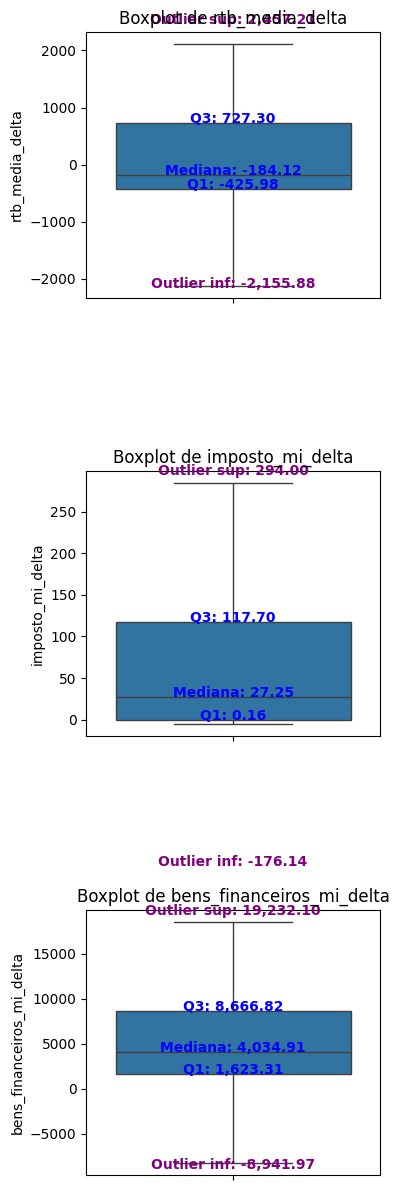

In [30]:
# Selecionando as colunas de variações (deltas)
columns = ['rtb_media_delta', 'imposto_mi_delta', 'bens_financeiros_mi_delta']

# Plotando boxplots
plot_boxplots(df_variacoes, columns, outline=False)



## Boxplot dos valores absolutos (2020)

> No notebook do IDEB, o professor inspecionou a distribuição do valor absoluto `IDEB_2023_(N_x_P)` por meio de boxplots.  
> 
> Na nossa base da Receita, fazemos o mesmo para os valores de **2020**, avaliando as distribuições absolutas de:  
> - `rtb_media`  
> - `imposto_mi`  
> - `bens_financeiros_mi`  
> 
> Isso complementa a análise das variações (Δ), mostrando como estão os valores finais em cada centil.


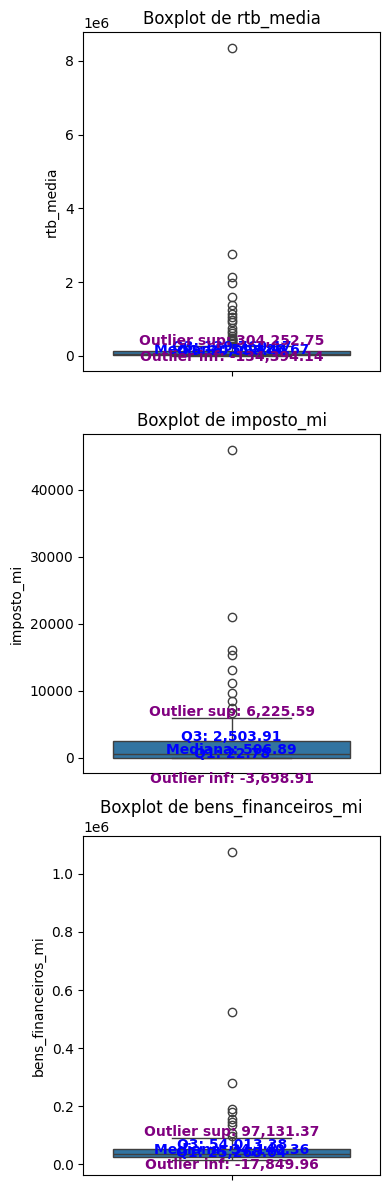

In [31]:
# Selecionando os valores absolutos de 2020
dados_2020 = dados[dados['ano'] == 2020]

columns = ['rtb_media', 'imposto_mi', 'bens_financeiros_mi']

# Boxplots dos valores absolutos de 2020
plot_boxplots(dados_2020, columns, outline=True)


## Boxplot dos valores absolutos (2019)

> No notebook do IDEB, o professor analisou os valores absolutos do ano inicial (2005) antes de comparar com 2023.  
> 
> Na nossa base da Receita, fazemos o mesmo com os valores de **2019**, avaliando a dispersão dos centis em:  
> - `rtb_media`  
> - `imposto_mi`  
> - `bens_financeiros_mi`


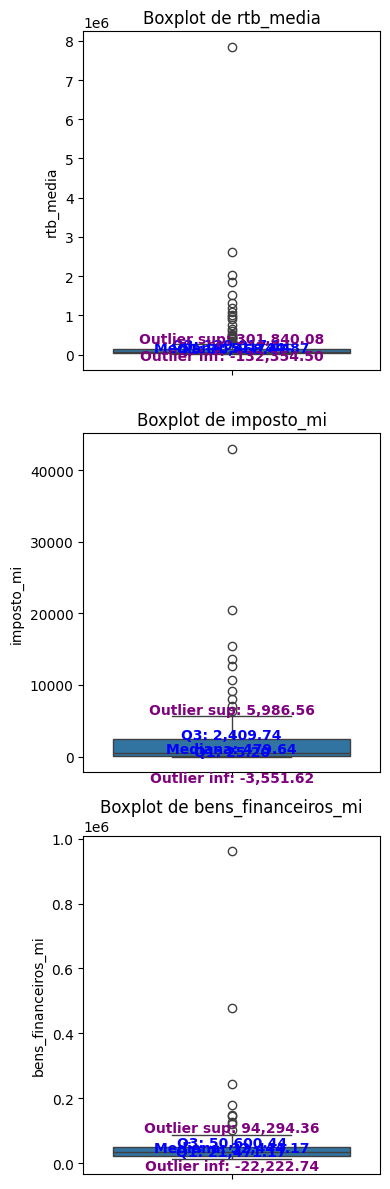

In [32]:
# Selecionando os valores absolutos de 2019
dados_2019 = dados[dados['ano'] == 2019]

columns = ['rtb_media', 'imposto_mi', 'bens_financeiros_mi']

# Boxplots dos valores absolutos de 2019
plot_boxplots(dados_2019, columns, outline=True)


## Rechecagem das colunas disponíveis

> No notebook do IDEB, o professor voltou a listar as colunas de `dados` após criar novas variáveis, para confirmar a estrutura do DataFrame.  
> 
> Na nossa base da Receita, as colunas permanecem as mesmas, mas mantemos esse passo por consistência metodológica e para validar antes da padronização.


In [33]:
# Rechecando as colunas do DataFrame após as transformações
print("📋 Colunas disponíveis no DataFrame 'dados':")
print(dados.columns)


📋 Colunas disponíveis no DataFrame 'dados':
Index(['ano', 'ente', 'centil', 'rtb_media', 'imposto_mi',
       'bens_financeiros_mi'],
      dtype='object')


## Padronização das variáveis para clusterização

> No notebook do IDEB, o professor utilizou o `StandardScaler` para normalizar os dados (`Var_IDEB`, `IDEB_2005`, `IDEB_2023`).  
> 
> Na nossa base da Receita, faremos o mesmo processo, mas aplicado às variações absolutas:  
> - `rtb_media_delta`  
> - `imposto_mi_delta`  
> - `bens_financeiros_mi_delta`  
> 
> Esse passo garante que todas as variáveis fiquem na **mesma escala**, evitando que valores muito grandes (como `rtb_media`) dominem o processo de clusterização.  
> Também salvamos o scaler (`scaler.pkl`) para garantir reprodutibilidade.


In [34]:
from sklearn.preprocessing import StandardScaler
import pickle

# Colunas selecionadas para clusterização
colunasSelecionadasCluster = [
    'rtb_media_delta',
    'imposto_mi_delta',
    'bens_financeiros_mi_delta'
]

# Atribuir 0 onde estiver NaN (segurança extra)
df_variacoes.fillna(0, inplace=True)

# Padronização
scaler = StandardScaler()
dadosPadronizada = scaler.fit_transform(df_variacoes[colunasSelecionadasCluster])

# Salvar o scaler
with open('scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

# Atualizar o dataframe com as variáveis padronizadas
dadosPadronizada = pd.DataFrame(
    dadosPadronizada,
    columns=[coluna + '_PADRONIZADA' for coluna in colunasSelecionadasCluster]
)

print("✅ Preview das variáveis padronizadas:")
display(dadosPadronizada.head())


✅ Preview das variáveis padronizadas:


,rtb_media_delta_PADRONIZADA,imposto_mi_delta_PADRONIZADA,bens_financeiros_mi_delta_PADRONIZADA
0,-0.209878,-0.380083,-0.016952
1,-0.226707,-0.379877,0.147551
2,-0.253880,-0.379582,-0.941168
3,-0.256523,-0.380319,-0.195364
4,-0.243744,-0.379847,-1.646993


## Padronização das variáveis de variação (Δ)

> No notebook do IDEB, o professor aplicou `StandardScaler` para normalizar `Var_IDEB`, `IDEB_2005` e `IDEB_2023`, salvando o scaler para uso futuro.  
> 
> Na nossa base da Receita, seguimos o mesmo processo para as variáveis de **variação absoluta entre 2020 e 2019**:  
> - `rtb_media_delta`  
> - `imposto_mi_delta`  
> - `bens_financeiros_mi_delta`  
> 
> Isso garante que todas as variáveis fiquem na **mesma escala**, evitando que uma variável com magnitude muito maior domine o processo de clusterização.


In [35]:
from sklearn.preprocessing import StandardScaler
import pickle

# Colunas selecionadas para clusterização
colunasSelecionadasCluster = [
    'rtb_media_delta',
    'imposto_mi_delta',
    'bens_financeiros_mi_delta'
]

# Garantindo que não há valores nulos
df_variacoes.fillna(0, inplace=True)

# Padronização com StandardScaler
scaler = StandardScaler()
dadosPadronizada = scaler.fit_transform(df_variacoes[colunasSelecionadasCluster])

# Salvar o scaler para reuso futuro
with open('scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

# Criar DataFrame com as variáveis padronizadas
dadosPadronizada = pd.DataFrame(
    dadosPadronizada,
    columns=[coluna + '_PADRONIZADA' for coluna in colunasSelecionadasCluster]
)

print("✅ Preview das variáveis padronizadas:")
display(dadosPadronizada.head())


✅ Preview das variáveis padronizadas:


,rtb_media_delta_PADRONIZADA,imposto_mi_delta_PADRONIZADA,bens_financeiros_mi_delta_PADRONIZADA
0,-0.209878,-0.380083,-0.016952
1,-0.226707,-0.379877,0.147551
2,-0.253880,-0.379582,-0.941168
3,-0.256523,-0.380319,-0.195364
4,-0.243744,-0.379847,-1.646993


## Lista de variáveis padronizadas

> No notebook do IDEB, o professor criou uma lista com os nomes das variáveis já padronizadas para facilitar o uso no PCA e no K-Means.  
> 
> Na nossa base da Receita, fazemos o mesmo com as variáveis de variação absoluta (Δ) padronizadas:  
> - `rtb_media_delta_PADRONIZADA`  
> - `imposto_mi_delta_PADRONIZADA`  
> - `bens_financeiros_mi_delta_PADRONIZADA`


In [36]:
# Criar a lista com os nomes das variáveis padronizadas
colunasSelecionadasPadronizadas = [coluna + '_PADRONIZADA' for coluna in colunasSelecionadasCluster]
colunasSelecionadasPadronizadas


['rtb_media_delta_PADRONIZADA',
 'imposto_mi_delta_PADRONIZADA',
 'bens_financeiros_mi_delta_PADRONIZADA']

## Concatenação dos DataFrames (originais + padronizados)

> No notebook do IDEB, o professor concatenou o DataFrame original com o DataFrame das variáveis padronizadas, mantendo todos os dados em um único objeto para análise.  
> 
> Na nossa base da Receita, fazemos o mesmo com `df_variacoes` (contendo as variações absolutas) e o DataFrame `dadosPadronizada` (com as versões escaladas das variáveis Δ).  
> 
> O resultado é um DataFrame consolidado que permite acessar facilmente tanto os valores originais quanto os padronizados.


In [37]:
# Concatenar os dois dataframes (original + padronizado)
dadosPadronizada = pd.concat([df_variacoes, dadosPadronizada], axis=1)

# Visualizar as colunas resultantes
print("📋 Colunas disponíveis após concatenação:")
print(dadosPadronizada.columns)


📋 Colunas disponíveis após concatenação:
Index(['centil', 'rtb_media_delta', 'imposto_mi_delta',
       'bens_financeiros_mi_delta', 'Região_Geográfica',
       'rtb_media_delta_PADRONIZADA', 'imposto_mi_delta_PADRONIZADA',
       'bens_financeiros_mi_delta_PADRONIZADA'],
      dtype='object')


## Comparação entre valores originais e padronizados

> No notebook do IDEB, o professor comparou estatísticas descritivas da variável `Var_IDEB` e de sua versão padronizada, garantindo que a transformação havia funcionado (média 0, desvio 1).  
> 
> Na nossa base da Receita, fazemos o mesmo com as variáveis de variação (Δ).  
> Abaixo, exemplificamos com `rtb_media_delta` e `rtb_media_delta_PADRONIZADA`.


In [38]:
# Comparando a variável original com a versão padronizada
dadosPadronizada[['rtb_media_delta', 'rtb_media_delta_PADRONIZADA']].describe()


,rtb_media_delta,rtb_media_delta_PADRONIZADA
count,114.000000,1.140000e+02
mean,11053.608158,1.558208e-17
std,53165.303408,1.004415e+00
min,-2790.160000,-2.615407e-01
25%,-425.975000,-2.168758e-01
50%,-184.125000,-2.123067e-01
75%,727.297500,-1.950878e-01
max,507512.570000,9.379253e+00


## Lista final de variáveis padronizadas para clusterização

> No notebook do IDEB, o professor criou a lista `colunasSelecionadasPadronizadas` com os nomes das colunas já padronizadas, para usá-las no PCA e no K-Means.  
> 
> Na nossa base da Receita, a lista contém as três variáveis de variação absoluta (Δ) já escaladas:
> - `rtb_media_delta_PADRONIZADA`  
> - `imposto_mi_delta_PADRONIZADA`  
> - `bens_financeiros_mi_delta_PADRONIZADA`


In [39]:
# Conferindo as colunas padronizadas que serão usadas no PCA e no K-Means
colunasSelecionadasPadronizadas


['rtb_media_delta_PADRONIZADA',
 'imposto_mi_delta_PADRONIZADA',
 'bens_financeiros_mi_delta_PADRONIZADA']

# Clusterização

> Nesta etapa aplicaremos o algoritmo **K-Means** sobre as variáveis padronizadas da Receita Federal.  
> O objetivo é agrupar os centis de renda em perfis semelhantes com base em:
> - Variação da renda tributável média (`rtb_media_delta`)  
> - Variação do imposto devido (`imposto_mi_delta`)  
> - Variação dos bens e direitos financeiros (`bens_financeiros_mi_delta`)  
> 
> A padronização foi feita anteriormente com o `StandardScaler`, e agora utilizaremos essas versões para garantir que todas as variáveis tenham o mesmo peso na formação dos clusters.


100%|██████████| 9/9 [00:05<00:00,  1.65it/s]


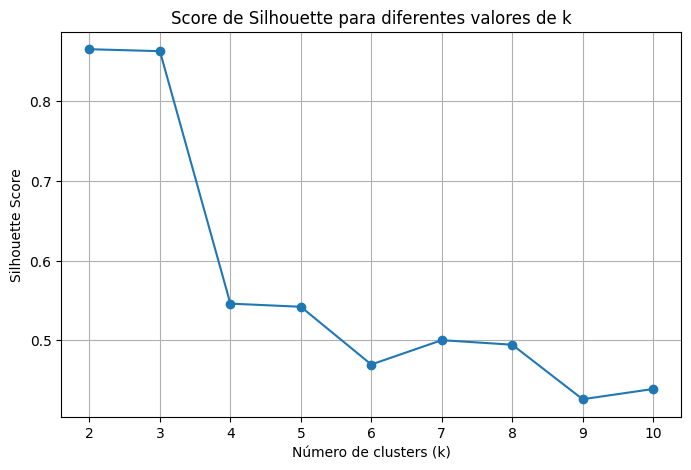

In [40]:
from tqdm import tqdm
from sklearn.metrics import silhouette_score
from sklearn.cluster import KMeans
from sklearn.impute import SimpleImputer
import matplotlib.pyplot as plt
import pandas as pd

# Criando uma cópia do dataset padronizado
df_cluster = dadosPadronizada.copy()

# Colunas usadas no clustering (já padronizadas)
col_corte = colunasSelecionadasPadronizadas

# Preenchendo possíveis NaN restantes
imputer = SimpleImputer(strategy="mean")
X = imputer.fit_transform(df_cluster[col_corte])

# Avaliando diferentes valores de k
silhouette_scores = []
K_range = range(2, 11)  # testando de 2 até 10 clusters

for k in tqdm(K_range):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X)
    score = silhouette_score(X, labels)
    silhouette_scores.append(score)

# Plotando os scores
plt.figure(figsize=(8,5))
plt.plot(K_range, silhouette_scores, marker="o")
plt.title("Score de Silhouette para diferentes valores de k")
plt.xlabel("Número de clusters (k)")
plt.ylabel("Silhouette Score")
plt.grid(True)
plt.show()


## Determinação do número ótimo de clusters

Até aqui, utilizamos o **Silhouette Score** para avaliar a qualidade da clusterização em diferentes valores de `k`.  
Agora, aplicaremos também o **método do cotovelo (Elbow Method)**, que analisa a soma dos quadrados intra-clusters (WCSS).  

A estratégia é:
- Rodar o K-Means para vários valores de `k` (de 1 até `maxCluster`).
- Salvar o WCSS de cada execução.
- Plotar o gráfico de `k` x `WCSS` para identificar o ponto de inflexão (*cotovelo*), que sugere o melhor valor de `k`.

A combinação do **Silhouette Score** e do **Elbow Method** nos dará uma escolha mais robusta do número ótimo de clusters.


100%|██████████| 18/18 [00:01<00:00, 17.85it/s]


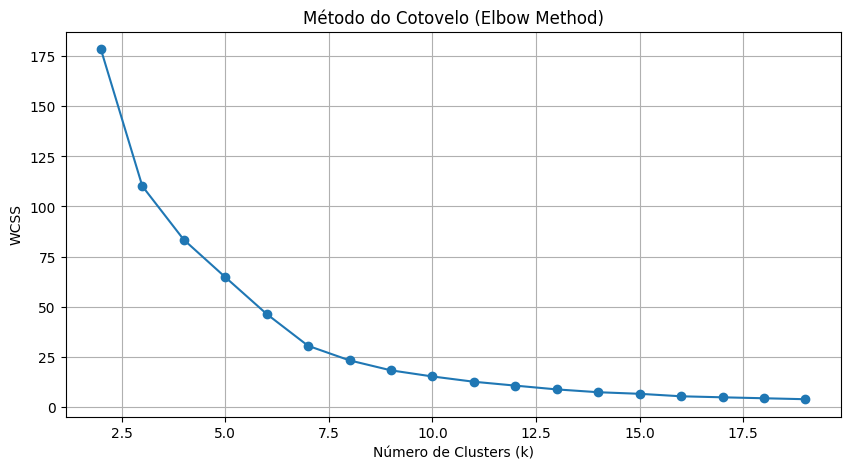

In [41]:
from tqdm import tqdm
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

# DataFrame para clusterização
df_cluster = dadosPadronizada.copy()
col_corte = colunasSelecionadasPadronizadas

# Listas para métricas
wcss = []
silhouette_scores = []

maxCluster = 20

for i in tqdm(range(2, maxCluster)):  # começamos em 2, já que k=1 não tem silhouette
    kmeans = KMeans(n_clusters=i, random_state=42, init='k-means++', n_init=10,
                    max_iter=1000, tol=1e-8)
    labels = kmeans.fit_predict(df_cluster[col_corte])

    # WCSS (soma dos quadrados intra-cluster)
    wcss.append(kmeans.inertia_)

    # Silhouette
    silhouette_scores.append(silhouette_score(df_cluster[col_corte], labels))

# Gráfico do método do cotovelo
plt.figure(figsize=(10,5))
plt.plot(range(2, maxCluster), wcss, marker='o')
plt.title('Método do Cotovelo (Elbow Method)')
plt.xlabel('Número de Clusters (k)')
plt.ylabel('WCSS')
plt.grid(True)
plt.show()


### Explicação
Esta célula executa um bloco de código referente à etapa seguinte do notebook. (Explicação detalhada será adicionada conforme a análise item a item).

In [ ]:
# Plotando o gráfico do método do cotovelo
plt.figure(figsize=(10, 6))
plt.plot(range(1, maxCluster), wcss, marker='o')
plt.title('Método do Cotovelo para Escolha do Número Ideal de Clusters')
plt.xlabel('Número de Clusters')
plt.ylabel('WCSS')
plt.ylim(ymin=0)
plt.grid(True)
plt.show()


### Explicação
Esta célula executa um bloco de código referente à etapa seguinte do notebook. (Explicação detalhada será adicionada conforme a análise item a item).

In [ ]:
dadosPadronizada.columns

### Explicação
Esta célula executa um bloco de código referente à etapa seguinte do notebook. (Explicação detalhada será adicionada conforme a análise item a item).

In [ ]:
df_cluster = dadosPadronizada[colunasSelecionadasCluster+colunasSelecionadasPadronizadas].copy()



i = 4
kmeans = KMeans(n_clusters = i, random_state = 42, init = 'k-means++', n_init = 10,
                max_iter=10000, tol = 1e-8)
kmeans.fit(df_cluster[col_corte])

df_cluster["cluster"] = kmeans.predict(df_cluster[col_corte])
df_cluster["cluster"] = [chr(x+65) for x in df_cluster.cluster]



df_cluster_info = df_cluster.groupby("cluster").median().reset_index()
df_cluster_count = df_cluster.groupby("cluster").count()[col_corte[0]].reset_index()
df_cluster_count.columns = ["cluster", "count"]

df_cluster_table = pd.merge(df_cluster_info, df_cluster_count, how="left", on="cluster")
df_cluster_table

#concatene apenas a coluna "cluster" do df_cluster ao dfPrefeitoBemPadronizada
dadosPadronizadaCluster = pd.concat([dadosPadronizada, df_cluster["cluster"]], axis=1)


### Explicação
Esta célula executa um bloco de código referente à etapa seguinte do notebook. (Explicação detalhada será adicionada conforme a análise item a item).

In [ ]:
df_cluster_info

### Explicação
Esta célula executa um bloco de código referente à etapa seguinte do notebook. (Explicação detalhada será adicionada conforme a análise item a item).

In [ ]:
#retirar as colunas colunasSelecionadasPadronizadas do df_cluster_info
df_cluster_info_view = df_cluster_table.drop(colunasSelecionadasPadronizadas, axis=1)

make_spider(df_cluster_info_view)

### Explicação
Esta célula executa um bloco de código referente à etapa seguinte do notebook. (Explicação detalhada será adicionada conforme a análise item a item).

In [ ]:
df_cluster.columns

### Explicação
Esta célula executa um bloco de código referente à etapa seguinte do notebook. (Explicação detalhada será adicionada conforme a análise item a item).

In [ ]:
# prompt: criar uma nova coluna DS_cluster, onde irei atribuir um rótulo, baseado no cluster

# Criar um dicionário para mapear os clusters para rótulos
cluster_labels = {
    'A': 'Baixa Performance',
    'B': 'Top 2023',
    'C': 'Melhores Evoluções',
    'D': 'Alta Performance Constante',
    'E': 'E',
    'F': 'F',
    'G': 'G',
    'H': 'H',
    'I': 'I'
     # Adicione mais rótulos conforme necessário
}

# Criar uma nova coluna 'DS_cluster' com os rótulos
dadosPadronizadaCluster['DS_cluster'] = dadosPadronizadaCluster['cluster'].map(cluster_labels)

# Exibir o dataframe com a nova coluna
dadosPadronizadaCluster[['cluster', 'DS_cluster']].head()


### Explicação
Esta célula executa um bloco de código referente à etapa seguinte do notebook. (Explicação detalhada será adicionada conforme a análise item a item).

In [ ]:
color_dict = {
    'Baixa Performance': 'red',
    'Top 2023': 'lightblue',
    'Melhores Evoluções': 'green',
    'Alta Performance Constante': 'blue'
}

### Explicação
Esta célula executa um bloco de código referente à etapa seguinte do notebook. (Explicação detalhada será adicionada conforme a análise item a item).

In [ ]:

import plotly.express as px

#colunasSelecionadas

# Supondo que 'col_corte' tenha três colunas
fig = px.scatter_3d(dadosPadronizadaCluster,
                    x=colunasSelecionadasCluster[0],
                    y=colunasSelecionadasCluster[1],
                    z=colunasSelecionadasCluster[2],
                    color='DS_cluster')

# Salvando o gráfico em um arquivo HTML
fig.write_html("grafico_clusters_3d.html")

# Exibindo o gráfico
fig.show()

### Explicação
Esta célula executa um bloco de código referente à etapa seguinte do notebook. (Explicação detalhada será adicionada conforme a análise item a item).

In [ ]:

import plotly.express as px

#colunasSelecionadas

# Supondo que 'col_corte' tenha três colunas
fig = px.scatter_3d(dadosPadronizadaCluster,
                    x=colunasSelecionadasCluster[0],
                    y=colunasSelecionadasCluster[1],
                    z=colunasSelecionadasCluster[2],
                    color='DS_cluster')

# Salvando o gráfico em um arquivo HTML
fig.write_html("grafico_clusters_3d.html")

# Exibindo o gráfico
fig.show()

### Explicação
Esta célula executa um bloco de código referente à etapa seguinte do notebook. (Explicação detalhada será adicionada conforme a análise item a item).

In [ ]:
import seaborn as sns
df_plot = dadosPadronizadaCluster.groupby("DS_cluster")[colunasSelecionadasCluster].mean().reset_index()

df_plot_melt = pd.melt(df_plot, id_vars=['DS_cluster'], value_vars= colunasSelecionadasCluster)

sns.barplot(x='DS_cluster', y='value', hue='variable', data=df_plot_melt)
plt.show()

### Explicação
Esta célula executa um bloco de código referente à etapa seguinte do notebook. (Explicação detalhada será adicionada conforme a análise item a item).

In [ ]:
colunasSelecionadasCluster

### Explicação
Esta célula executa um bloco de código referente à etapa seguinte do notebook. (Explicação detalhada será adicionada conforme a análise item a item).

In [ ]:
plt.figure(figsize=(10, 6))
Var = 'Var_IDEB'
sns.kdeplot(data=dadosPadronizadaCluster, x=Var, hue='DS_cluster', fill=True,  palette='Set2')
plt.title(f'Histograma da Variável {Var} por Cluster')
plt.xlabel(f'{Var}')
plt.ylabel('Frequência')
plt.show()

### Explicação
Esta célula executa um bloco de código referente à etapa seguinte do notebook. (Explicação detalhada será adicionada conforme a análise item a item).

In [ ]:
plt.figure(figsize=(10, 6))
Var = 'IDEB_2023_(N_x_P)'
sns.kdeplot(data=dadosPadronizadaCluster, x=Var, hue='DS_cluster', fill=True,  palette='Set2')
plt.title(f'Histograma da Variável {Var} por Cluster')
plt.xlabel(f'{Var}')
plt.ylabel('Frequência')
plt.show()

### Explicação
Esta célula executa um bloco de código referente à etapa seguinte do notebook. (Explicação detalhada será adicionada conforme a análise item a item).

In [ ]:
plt.figure(figsize=(10, 6))
Var = 'IDEB_2005_(N_x_P)'
sns.kdeplot(data=dadosPadronizadaCluster, x=Var, hue='DS_cluster', fill=True,  palette='Set2')
plt.title(f'Histograma da Variável {Var} por Cluster')
plt.xlabel(f'{Var}')
plt.ylabel('Frequência')
plt.show()


### Explicação
Esta célula executa um bloco de código referente à etapa seguinte do notebook. (Explicação detalhada será adicionada conforme a análise item a item).

In [ ]:
df = dadosPadronizadaCluster.copy()
category_col = 'Rede'
split_col = 'DS_cluster'
plot_pie_charts(df, category_col, split_col)

### Explicação
Esta célula executa um bloco de código referente à etapa seguinte do notebook. (Explicação detalhada será adicionada conforme a análise item a item).

### Explicação
Esta célula executa um bloco de código referente à etapa seguinte do notebook. (Explicação detalhada será adicionada conforme a análise item a item).

### Explicação
Esta célula executa um bloco de código referente à etapa seguinte do notebook. (Explicação detalhada será adicionada conforme a análise item a item).

In [ ]:
df = dadosPadronizadaCluster.copy()
category_col = 'DS_cluster'
split_col = 'Rede'
plot_pie_charts(df, category_col, split_col, color_dict)

### Explicação
Esta célula executa um bloco de código referente à etapa seguinte do notebook. (Explicação detalhada será adicionada conforme a análise item a item).

In [ ]:
dadosPadronizadaCluster.columns

### Explicação
Esta célula executa um bloco de código referente à etapa seguinte do notebook. (Explicação detalhada será adicionada conforme a análise item a item).

In [ ]:
df = dadosPadronizadaCluster.copy()
category_col = 'Região_Geográfica'
split_col = 'DS_cluster'
plot_pie_charts(df, category_col, split_col)

### Explicação
Esta célula executa um bloco de código referente à etapa seguinte do notebook. (Explicação detalhada será adicionada conforme a análise item a item).

In [ ]:
df = dadosPadronizadaCluster.copy()
category_col = 'DS_cluster'
split_col = 'Região_Geográfica'
plot_pie_charts(df, category_col, split_col)

### Explicação
Esta célula executa um bloco de código referente à etapa seguinte do notebook. (Explicação detalhada será adicionada conforme a análise item a item).

In [ ]:
df = dadosPadronizadaCluster.copy()
category_col = 'Sigla_da_UF'
split_col = 'DS_cluster'
plot_pie_charts(df, category_col, split_col)

### Explicação
Esta célula executa um bloco de código referente à etapa seguinte do notebook. (Explicação detalhada será adicionada conforme a análise item a item).

In [ ]:
df = dadosPadronizadaCluster.copy()
category_col = 'DS_cluster'
split_col = 'Sigla_da_UF'
plot_pie_charts(df, category_col, split_col)

# Regras de Associação

### Explicação
Esta célula executa um bloco de código referente à etapa seguinte do notebook. (Explicação detalhada será adicionada conforme a análise item a item).

In [ ]:
dadosPadronizadaCluster.head()


### Explicação
Esta célula executa um bloco de código referente à etapa seguinte do notebook. (Explicação detalhada será adicionada conforme a análise item a item).

In [ ]:
# Função para criar faixas de quartis
def criar_faixas_quartis(df, colunas):
    for coluna in colunas:
        if pd.api.types.is_numeric_dtype(df[coluna]):
            quartis = df[coluna].quantile([0.25, 0.5, 0.75])
            df[coluna + '_Quartis'] = pd.cut(df[coluna], bins=[-float('inf'), quartis[0.25], quartis[0.5], quartis[0.75], float('inf')],
                                              labels=['Q1', 'Q2', 'Q3', 'Q4'], include_lowest=True, duplicates='drop')
    return df

# Colunas numéricas para criar faixas de quartis
colunas_numericas = ['Taxa_de_Aprovação_2005_6º_a_9º_ano', 'Taxa_de_Aprovação_2023_6º_a_9º_ano',
                    'Nota_SAEB_2005_Matemática', 'Nota_SAEB_2005_Língua_Portuguesa',
                    'Nota_SAEB_2023_Matemática', 'Nota_SAEB_2023_Língua_Portuguesa',
                    'IDEB_2005_(N_x_P)', 'IDEB_2023_(N_x_P)', 'Var_IDEB']


# Aplicar a função para criar as faixas de quartis
dadosPadronizadaCluster = criar_faixas_quartis(dadosPadronizadaCluster, colunas_numericas)

# Exibir as primeiras linhas do DataFrame com as novas colunas
print(dadosPadronizadaCluster.head())


### Explicação
Esta célula executa um bloco de código referente à etapa seguinte do notebook. (Explicação detalhada será adicionada conforme a análise item a item).

In [ ]:
dadosPadronizadaCluster.columns.to_list()

### Explicação
Esta célula executa um bloco de código referente à etapa seguinte do notebook. (Explicação detalhada será adicionada conforme a análise item a item).

In [ ]:
# Renomear as colunas
novos_nomes = {
    'Taxa_de_Aprovação_2005_6º_a_9º_ano': 'TxApr_2005',
    'Taxa_de_Aprovação_2023_6º_a_9º_ano': 'TxApr_2023',
    'Nota_SAEB_2005_Matemática': 'Nota_Mat_2005',
    'Nota_SAEB_2005_Língua_Portuguesa': 'Nota_Por_2005',
    'Nota_SAEB_2023_Matemática': 'Nota_Mat_2023',
    'Nota_SAEB_2023_Língua_Portuguesa': 'Nota_Por_2023',
    'IDEB_2005_(N_x_P)': 'IDEB_2005',
    'IDEB_2023_(N_x_P)': 'IDEB_2023',
    'Var_IDEB': 'Var_IDEB',
    'Região_Geográfica': 'Regiao',
    'Var_IDEB_PADRONIZADA': 'Var_IDEB_Pad',
    'IDEB_2005_(N_x_P)_PADRONIZADA': 'IDEB_2005_Pad',
    'IDEB_2023_(N_x_P)_PADRONIZADA': 'IDEB_2023_Pad',
    'Taxa_de_Aprovação_2005_6º_a_9º_ano_Quartis': 'TxApr_2005_Qrt',
    'Taxa_de_Aprovação_2023_6º_a_9º_ano_Quartis': 'TxApr_2023_Qrt',
    'Nota_SAEB_2005_Matemática_Quartis': 'Nota_Mat_2005_Qrt',
    'Nota_SAEB_2005_Língua_Portuguesa_Quartis': 'Nota_Por_2005_Qrt',
    'Nota_SAEB_2023_Matemática_Quartis': 'Nota_Mat_2023_Qrt',
    'Nota_SAEB_2023_Língua_Portuguesa_Quartis': 'Nota_Por_2023_Qrt',
    'IDEB_2005_(N_x_P)_Quartis': 'IDEB_2005_Qrt',
    'IDEB_2023_(N_x_P)_Quartis': 'IDEB_2023_Qrt',
    'Var_IDEB_Quartis': 'Var_IDEB_Qrt'
}

dadosPadronizadaCluster = dadosPadronizadaCluster.rename(columns=novos_nomes)
dadosPadronizadaCluster.columns


### Explicação
Esta célula executa um bloco de código referente à etapa seguinte do notebook. (Explicação detalhada será adicionada conforme a análise item a item).

In [ ]:
dadosPadronizadaCluster.head()

### Explicação
Esta célula executa um bloco de código referente à etapa seguinte do notebook. (Explicação detalhada será adicionada conforme a análise item a item).

In [ ]:
dadosPadronizadaCluster.columns.to_list()

### Explicação
Esta célula executa um bloco de código referente à etapa seguinte do notebook. (Explicação detalhada será adicionada conforme a análise item a item).

In [ ]:

# Lista de colunas que você deseja manter
colunas_desejadas = [
    'Sigla_da_UF',
    'Código_do_Município',
    'Nome_do_Município',
    'Rede',
    'Regiao',
    'DS_cluster',
    'TxApr_2005_Qrt',
    'Nota_Mat_2005_Qrt',
    'Nota_Por_2005_Qrt',
    'IDEB_2005_Qrt'
]

# Selecionando apenas as colunas desejadas
dadosPadronizadaCluster_filtrado = dadosPadronizadaCluster[colunas_desejadas]

# Exibindo as primeiras linhas do DataFrame filtrado para confirmar a operação
print(dadosPadronizadaCluster_filtrado.head())


### Explicação
Esta célula executa um bloco de código referente à etapa seguinte do notebook. (Explicação detalhada será adicionada conforme a análise item a item).

In [ ]:
dadosPadronizadaCluster_filtrado.columns.to_list()

### Explicação
Esta célula executa um bloco de código referente à etapa seguinte do notebook. (Explicação detalhada será adicionada conforme a análise item a item).

In [ ]:
# Lista de colunas que não serão transformadas
colunas_excluir = ['Código_do_Município', 'Nome_do_Município']

# Criar um novo DataFrame que exclui as colunas especificadas
df_subconjunto = dadosPadronizadaCluster_filtrado.drop(columns=colunas_excluir)

# Aplicar one-hot encoding a todas as colunas restantes
# pd.get_dummies() irá identificar automaticamente as colunas categóricas e
# criar as variáveis dummy correspondentes.
df_onehot = pd.get_dummies(df_subconjunto)

# Exibir as primeiras linhas do DataFrame resultante para conferência
print(df_onehot.head())

### Explicação
Esta célula executa um bloco de código referente à etapa seguinte do notebook. (Explicação detalhada será adicionada conforme a análise item a item).

In [ ]:
!pip install pyvis
!pip install mlxtend
!pip install pandas
!pip install matplotlib
!pip install networkx
!pip install numpy


### Explicação
Esta célula executa um bloco de código referente à etapa seguinte do notebook. (Explicação detalhada será adicionada conforme a análise item a item).

In [ ]:
from mlxtend.preprocessing import TransactionEncoder
from mlxtend.frequent_patterns import apriori, association_rules
import pandas as pd
import random
import matplotlib.pyplot as plt
import networkx as nx
import seaborn as sns

### Explicação
Esta célula executa um bloco de código referente à etapa seguinte do notebook. (Explicação detalhada será adicionada conforme a análise item a item).

In [ ]:
df_onehot.columns.to_list()

### Explicação
Esta célula executa um bloco de código referente à etapa seguinte do notebook. (Explicação detalhada será adicionada conforme a análise item a item).

In [ ]:
from mlxtend.frequent_patterns import association_rules, apriori

frequent_items = apriori(df_onehot, min_support = 0.05,use_colnames = True)
frequent_items

### Explicação
Esta célula executa um bloco de código referente à etapa seguinte do notebook. (Explicação detalhada será adicionada conforme a análise item a item).

In [ ]:
rules = association_rules(frequent_items, metric = "lift", min_threshold = 1)
rules.sort_values('lift', ascending = False, inplace = True)
rules

### Explicação
Esta célula executa um bloco de código referente à etapa seguinte do notebook. (Explicação detalhada será adicionada conforme a análise item a item).

In [ ]:
grules = rules[rules['lift'] > 1]
grules.shape

### Explicação
Esta célula executa um bloco de código referente à etapa seguinte do notebook. (Explicação detalhada será adicionada conforme a análise item a item).

In [ ]:

rules_consequent_1 = grules[grules['consequents'].apply(lambda x: len(x) == 1)]
display(rules_consequent_1)


### Explicação
Esta célula executa um bloco de código referente à etapa seguinte do notebook. (Explicação detalhada será adicionada conforme a análise item a item).

In [ ]:

rules_antecedent_1 = grules[grules['antecedents'].apply(lambda x: len(x) == 1)]
display(rules_antecedent_1)

### Explicação
Esta célula executa um bloco de código referente à etapa seguinte do notebook. (Explicação detalhada será adicionada conforme a análise item a item).

In [ ]:
rules_consequent_1_DS_cluster = rules[
    rules['antecedents'].apply(lambda x: len(x) == 1 and any('DS_cluster_B' in str(item) for item in x))
]

rules_consequent_1_DS_cluster = rules_consequent_1_DS_cluster[
    rules['confidence'].apply(lambda x: x>= 0.3)
]

rules_filtered = rules_consequent_1_DS_cluster[
    rules_consequent_1_DS_cluster['consequents'].apply(lambda x: len(x) <= 2)
]

display(rules_filtered)

### Explicação
Esta célula executa um bloco de código referente à etapa seguinte do notebook. (Explicação detalhada será adicionada conforme a análise item a item).

In [ ]:
import warnings
warnings.filterwarnings("ignore", category=DeprecationWarning)

pd.set_option('display.max_colwidth', None)

import pandas as pd
import networkx as nx
from pyvis.network import Network
from google.colab import files

def make_graph_2(grules):
    G = nx.DiGraph()

    # Adicionando nós e arestas
    for index, row in grules.iterrows():
        # Criando rótulos para os nós de antecedente e consequente
        antecedent_items = sorted(map(str, row['antecedents']))
        consequent_items = sorted(map(str, row['consequents']))
        antecedent_label = ', '.join(antecedent_items)
        consequent_label = ', '.join(consequent_items)

        # Adicionando os nós de antecedente e consequente se ainda não existirem
        if not G.has_node(antecedent_label):
            G.add_node(antecedent_label, title=antecedent_label)
        if not G.has_node(consequent_label):
            G.add_node(consequent_label, title=consequent_label)

        # Adicionando uma aresta entre o antecedente e o consequente
        G.add_edge(
            antecedent_label,
            consequent_label,
            title=f"Confiança: {row['confidence']:.2f}, Lift: {row['lift']:.2f}",
            confidence=row['confidence'],
            lift=row['lift']
        )

    # Criando a rede com pyvis
    net = Network(
        height="750px",
        width="100%",
        bgcolor="#222222",
        font_color="white",
        notebook=True,
        directed=True,
        cdn_resources='in_line'
    )

    # Convertendo o grafo networkx para pyvis
    net.from_nx(G)

    # Ajustando estilos e interações
    for node in net.nodes:
        node_label = node['label']
        node['title'] = node_label
        node['shape'] = 'box'  # Opcional: para melhor visualização de conjuntos de itens

        # Verificando se o nó representa um único item
        if ',' not in node_label:
            # Verificando se o item começa com 'DS_cluster'
            if node_label.startswith('DS_cluster'):
                # Destaque para os nós que atendem ao critério
                node['color'] = 'red'         # Cor diferenciada
                node['font'] = {'size': 14}   # Fonte maior
                node['borderWidth'] = 2       # Borda mais espessa
                node['size'] = 40             # Nó maior
            else:
                # Estilo padrão para nós individuais
                node['color'] = '#1f78b4'
                node['size'] = 5
                node['font'] = {'size': 2}   # Fonte menor
        else:
            # Estilo para nós que representam múltiplos itens
            node['color'] = '#6a3d9a'
            node['size'] = 5
            node['font'] = {'size': 2}   # Fonte menor

    for edge in net.edges:
        edge['title'] = edge['title']
        edge['value'] = edge['confidence']  # Ajusta a espessura da aresta com base na confiança

    # Habilitando a física para movimentação dinâmica dos nós
    net.show_buttons(filter_=['physics'])
    net.toggle_physics(True)

    # Salvando e fazendo o download do grafo
    net.save_graph("supermarket_associations_directed.html")
    files.download("supermarket_associations_directed.html")


### Explicação
Esta célula executa um bloco de código referente à etapa seguinte do notebook. (Explicação detalhada será adicionada conforme a análise item a item).

In [ ]:
make_graph2(rules_filtered)

### Explicação
Esta célula executa um bloco de código referente à etapa seguinte do notebook. (Explicação detalhada será adicionada conforme a análise item a item).